<a href="https://colab.research.google.com/github/cdube89128/DATA_620/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 - Project 1 - Dune Characters
### DATA 620
### Catherine Dube

**HW Prompt**

This project assignment is to:

* Identify and load a network dataset that has some categorical information available for each node.
* For each of the nodes in the dataset, calculate degree centrality and eigenvector centrality.
* Compare your centrality measures across your categorical groups.

# Project Starts Below

# Section 1: The Dune Premise and Hypothesis of the Project

**Context:** As a fan of the Dune franchise, I thought that it would be really interesting to look at this network of characters. For those who are unfamiliar, Dune is a sci-fi world that involves a great deal of politics, and a number of houses or "cultures" that are vying for control.

The Bene Gesserit group is one of the groups vying fpr control. BAsed on the books/movies, they appear to operate in the shadows, but to have their tendrils in almost everywhere. Based on that, I want to test the hypothesis:

**Hypothesis:** Bene Gesserit characters will display a significantly higher Eigenvector Centrality than non-Bene Gesserit characters.

* Null hypothesis: There is no significant difference in Eigenvector Centrality between Bene Gesserit characters and non-Bene Gesserit characters in the network graph.

* Alt. hypothesis: The Bene Gesserit characters have a statistically significantly higher mean Eigenvector Centrality than non-Bene Gesserit characters, supporting the 'Hidden Hand' theory of structural influence.

## Section 2: Data Loading, Cleaning, and Exploratory Analysis

In [72]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.lines import Line2D

In [73]:
# load in Dune character network dataset
# (which I put a copy of in my Github repo)
url = 'https://github.com/cdube89128/DATA_620/raw/refs/heads/main/duneCharacters_kaggle.csv'
df = pd.read_csv(url, encoding= 'latin-1' )

# Cleaning; removing backslashes and extra spaces
df.columns = df.columns.str.replace(r'\\', '', regex=True).str.strip()


#### Exploratory Data Analysis
Before building the NetworkX graph, I'm going to look at the edge list for missing values. In network analysis, every edge requires a valid source node and target node.

If a character has no outgoing relationships (a missing value in the `to` column) AND they are never targeted by another character, then they will have a degree of centrality of 0. I will **filter out** these characters/nodes/

In [74]:
# Count the raw data and missing targets
total_rows = len(df)
missing_targets = df['to'].isna().sum()

print(f"Total entries in raw data: {total_rows}")
print(f"Rows missing a target relationship ('to' is NaN): {missing_targets}\n")

# Identify unique characters across source and target columns
source_chars = set(df['Character'].dropna().unique())
target_chars = set(df['to'].dropna().unique())
all_chars = source_chars.union(target_chars)

# Classify character connectivity
chars_with_outgoing = set(df.dropna(subset=['to'])['Character'].unique())

# Characters who only receive relationships but initiate none
targets_only = (source_chars - chars_with_outgoing) & target_chars

# Characters with 0 incoming, 0 outgoing edges
pure_isolates = source_chars - chars_with_outgoing - target_chars

print(f"--- Network Node Summary ---")
print(f"Total unique characters across entire dataset: {len(all_chars)}")
print(f"Characters initiating relationships: {len(chars_with_outgoing)}")
print(f"Characters that only receive relationships: {len(targets_only)}")
print(f"Completely isolated characters to be dropped: {len(pure_isolates)}")

# Drop the isolated characters
edges_df = df.dropna(subset=['to']).copy()

Total entries in raw data: 107
Rows missing a target relationship ('to' is NaN): 36

--- Network Node Summary ---
Total unique characters across entire dataset: 79
Characters initiating relationships: 51
Characters that only receive relationships: 2
Completely isolated characters to be dropped: 26


## Section 3: Network Building

This includes calculating degree centrality and eigenvector centrality.

In [75]:
# Build the network graph from the clean list
G = nx.from_pandas_edgelist(edges_df, source='Character', target='to')

# Create a dictionary mapping
allegiance_map = df.set_index('Character')['House_Allegiance'].to_dict()

# Attach the faction data to the network nodes
nx.set_node_attributes(G, allegiance_map, name='Allegiance')

# Calculate the centrality metrics
degree_dict = nx.degree_centrality(G)
eigen_dict = nx.eigenvector_centrality(G, max_iter=1000)

# Extract the network data into a clean DataFrame for the statistical comparison
results_df = pd.DataFrame({
    'Character': list(G.nodes()),
    'Allegiance': [G.nodes[n].get('Allegiance') for n in G.nodes()],
    'Degree_Centrality': [degree_dict[n] for n in G.nodes()],
    'Eigenvector_Centrality': [eigen_dict[n] for n in G.nodes()]
})

# Peek the output
print(results_df.head())

            Character Allegiance  Degree_Centrality  Eigenvector_Centrality
0      Abulurd Rabban  Harkonnen           0.019231                0.049786
1  Vladimir Harkonnen  Harkonnen           0.134615                0.246691
2      Anirul Corrino    Corrino           0.019231                0.021077
3  Shaddam Corrino IV    Corrino           0.076923                0.104435
4         Chani Kynes   Atreides           0.038462                0.154906


=== Top 10 Characters by Degree Centrality (Direct Connections) ===
         Character Allegiance  Degree_Centrality
     Paul Atreides        NaN           0.288462
   Leto Atreides I   Atreides           0.211538
Vladimir Harkonnen  Harkonnen           0.134615
           Stilgar   Atreides           0.134615
        Liet Kynes   Atreides           0.096154
Shaddam Corrino IV    Corrino           0.076923
             Jamis   Atreides           0.076923
  Jessica Atreides   Atreides           0.057692
      Duncan Idaho   Atreides           0.057692
             Nisai   Atreides           0.057692

=== Top 10 Characters by Eigenvector Centrality (Network Influence) ===
         Character Allegiance  Eigenvector_Centrality
     Paul Atreides        NaN                0.519187
   Leto Atreides I   Atreides                0.454240
           Stilgar   Atreides                0.312470
        Liet Kynes   Atreides                0.248377
Vladimir Harkonnen  Harkonnen                0.246

/tmp/ipykernel_1562/449527926.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1562/449527926.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


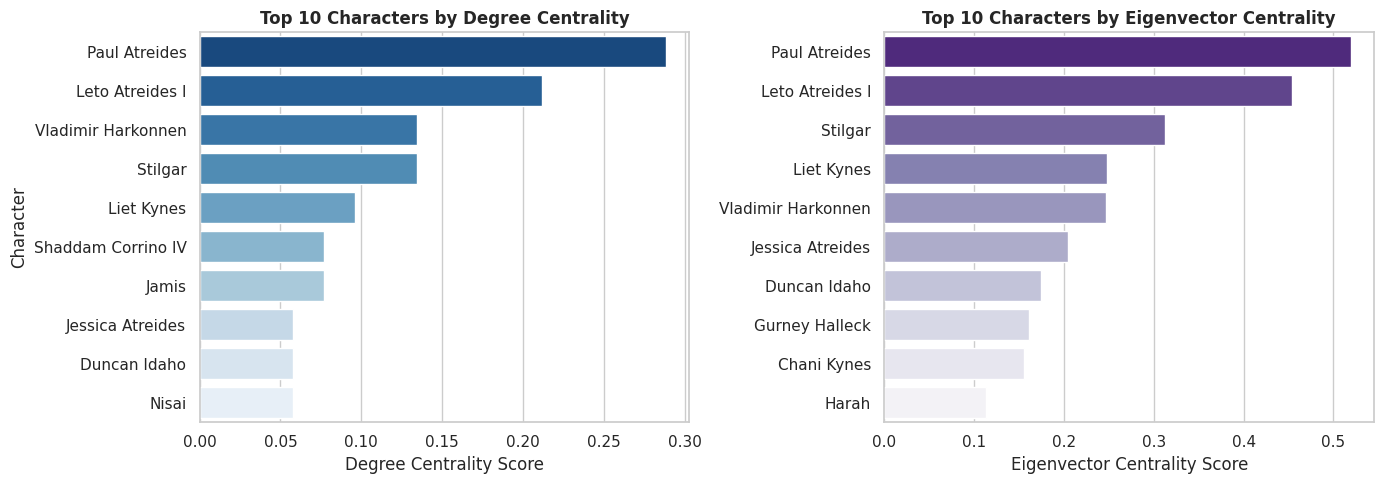

In [76]:
# Top 10 characters by Degree Centrality (most direct connections / local impact)
top_degree = (
    results_df.sort_values(by="Degree_Centrality", ascending=False)
    .head(10)[["Character", "Allegiance", "Degree_Centrality"]]
    .reset_index(drop=True)
)

# Top 10 characters by Eigenvector Centrality (connected to other highly connected nodes / systemic influence)
top_eigen = (
    results_df.sort_values(by="Eigenvector_Centrality", ascending=False)
    .head(10)[["Character", "Allegiance", "Eigenvector_Centrality"]]
    .reset_index(drop=True)
)

print("=== Top 10 Characters by Degree Centrality (Direct Connections) ===")
print(top_degree.to_string(index=False))

print("\n=== Top 10 Characters by Eigenvector Centrality (Network Influence) ===")
print(top_eigen.to_string(index=False))

# --- Optional: Visual Comparison of Top Impact Characters ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot top degree centrality
sns.barplot(
    data=top_degree,
    x="Degree_Centrality",
    y="Character",
    palette="Blues_r",
    ax=axes[0],
)
axes[0].set_title(
    "Top 10 Characters by Degree Centrality", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Degree Centrality Score")
axes[0].set_ylabel("Character")

# Plot top eigenvector centrality
sns.barplot(
    data=top_eigen,
    x="Eigenvector_Centrality",
    y="Character",
    palette="Purples_r",
    ax=axes[1],
)
axes[1].set_title(
    "Top 10 Characters by Eigenvector Centrality",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Eigenvector Centrality Score")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Creating a visualization of the network.

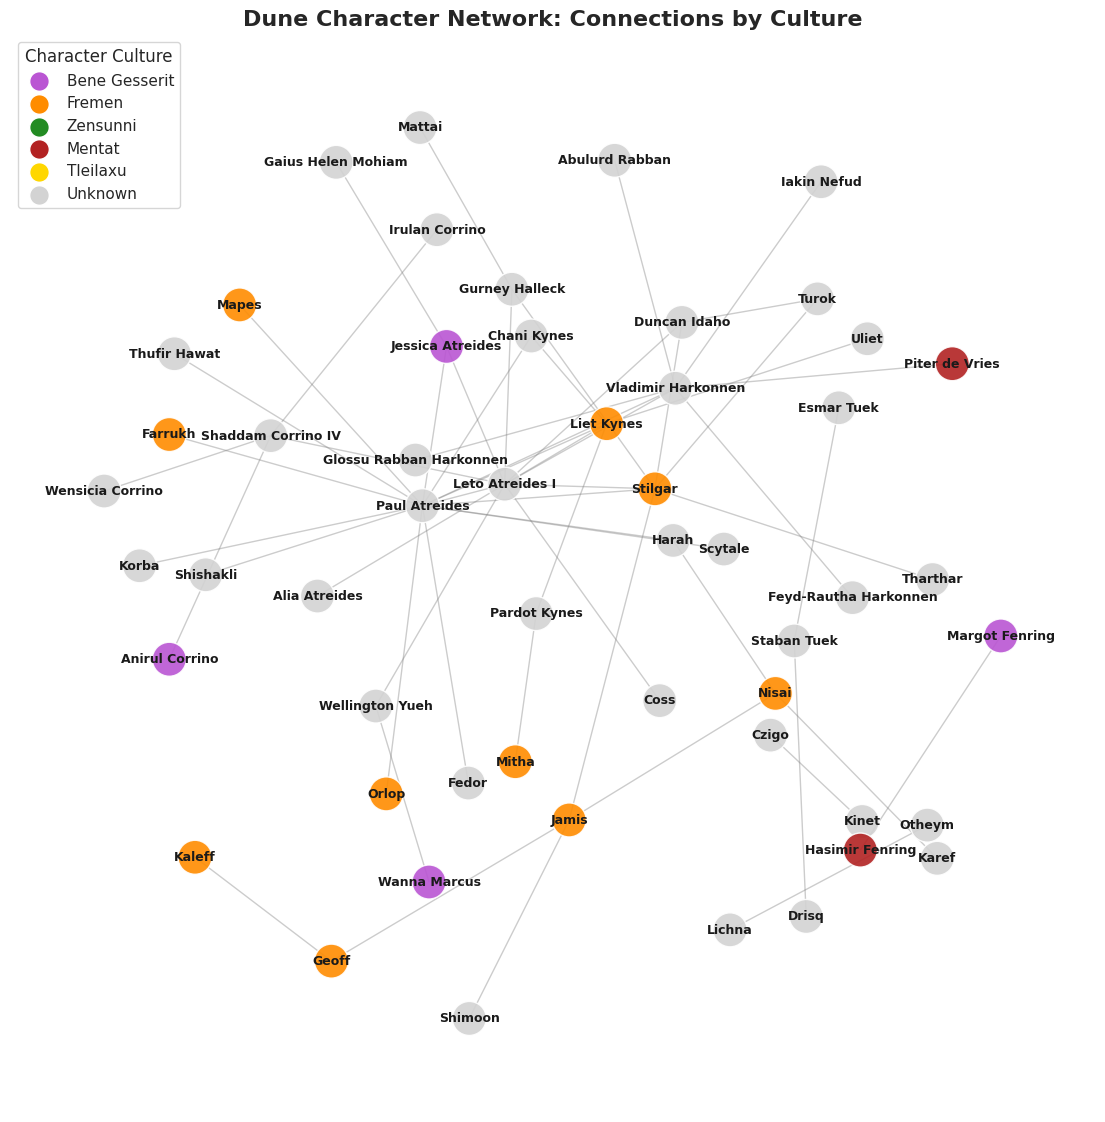

In [77]:
# Missing/Blank = 'Unknown'
df['Culture'] = df['Culture'].fillna('Unknown')

# Update the network nodes with the cleaned Culture attribute
culture_map = df.set_index('Character')['Culture'].to_dict()
nx.set_node_attributes(G, culture_map, name='Culture')

# Define color dictionary for the cultures
color_map = {
    'Bene Gesserit': 'mediumorchid',  # Purple for the sisterhood
    'Fremen': 'darkorange',           # Orange for Arrakis
    'Zensunni': 'forestgreen',
    'Mentat': 'firebrick',
    'Tleilaxu': 'gold',
    'Unknown': 'lightgray'            # Gray for all the blanks we filled
}

# Generate a list of colors
node_colors = [color_map.get(G.nodes[n].get('Culture', 'Unknown'), 'lightgray') for n in G.nodes()]

# Plot setup
plt.figure(figsize=(14, 14))
# spring_layout uses a force-directed algorithm; 'k' spaces the nodes out
pos = nx.spring_layout(G, k=0.6, seed=42)

# Draw graph
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600, alpha=0.9, edgecolors='white')
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Legend
for culture, color in color_map.items():
    plt.scatter([], [], c=color, label=culture, s=200, edgecolors='white')
plt.legend(title='Character Culture', scatterpoints=1, frameon=True, loc='upper left')

plt.title("Dune Character Network: Connections by Culture", fontsize=16, fontweight='bold')
plt.axis('off')  # Hides the x and y axes for a cleaner look
plt.show()

From the above visualization, I'm noticing a lot of "Unknown" nodes, who aren't known to be specifically of a specific culture. I'm also seeing only a few Bene Gesserit nodes, despite the fact that within the story, they are known to be involved everywhere.

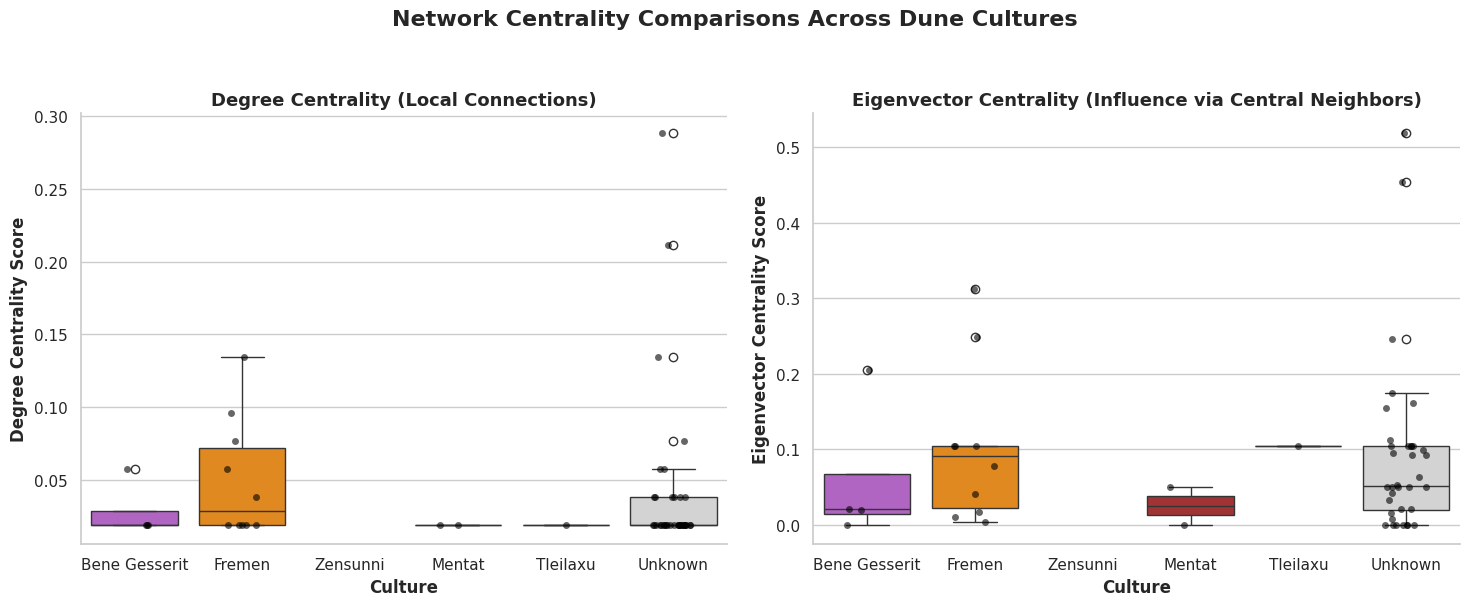

--- Degree Centrality (Local Connections) ---
               count     min     25%     50%     75%     max
Culture                                                     
Bene Gesserit    4.0  0.0192  0.0192  0.0192  0.0288  0.0577
Fremen          10.0  0.0192  0.0192  0.0288  0.0721  0.1346
Mentat           2.0  0.0192  0.0192  0.0192  0.0192  0.0192
Tleilaxu         1.0  0.0192  0.0192  0.0192  0.0192  0.0192
Unknown         36.0  0.0192  0.0192  0.0192  0.0385  0.2885


--- Eigenvector Centrality (Influence via Central Neighbors) ---
               count     min     25%     50%     75%     max
Culture                                                     
Bene Gesserit    4.0  0.0000  0.0145  0.0202  0.0670  0.2048
Fremen          10.0  0.0033  0.0223  0.0912  0.1048  0.3125
Mentat           2.0  0.0000  0.0124  0.0249  0.0373  0.0498
Tleilaxu         1.0  0.1048  0.1048  0.1048  0.1048  0.1048
Unknown         36.0  0.0000  0.0197  0.0512  0.1048  0.5192


In [78]:
# Clean the encoding artifact 'ÿ' from the Culture column and handle missing values
df['Culture'] = df['Culture'].str.replace('ÿ', '', regex=False).fillna('Unknown')

# Map the cleaned 'Culture' column into results_df so seaborn can use it
culture_map = df.set_index('Character')['Culture'].to_dict()
results_df['Culture'] = results_df['Character'].map(culture_map)

# Plot Setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Network Centrality Comparisons Across Dune Cultures",
             fontsize=16, fontweight='bold', y=1.02)

# Define the order of cultures to display on the x-axis
culture_order = ['Bene Gesserit', 'Fremen', 'Zensunni', 'Mentat', 'Tleilaxu', 'Unknown']

# Define color dictionary for the cultures
color_map = {
    'Bene Gesserit': 'mediumorchid',
    'Fremen': 'darkorange',
    'Zensunni': 'forestgreen',
    'Mentat': 'firebrick',
    'Tleilaxu': 'gold',
    'Unknown': 'lightgray'
}

# Plot Degree Centrality Boxplot
sns.boxplot(data=results_df, x='Culture', y='Degree_Centrality', hue='Culture', order=culture_order, ax=ax1, palette=color_map, legend=False)
sns.stripplot(data=results_df, x='Culture', y='Degree_Centrality', order=culture_order, ax=ax1, color='black', alpha=0.6, jitter=0.2)
ax1.set_title("Degree Centrality (Local Connections)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Culture", fontweight='bold')
ax1.set_ylabel("Degree Centrality Score", fontweight='bold')

# Plot Eigenvector Centrality Boxplot
sns.boxplot(data=results_df, x='Culture', y='Eigenvector_Centrality', hue='Culture', order=culture_order, ax=ax2, palette=color_map, legend=False)
sns.stripplot(data=results_df, x='Culture', y='Eigenvector_Centrality', order=culture_order, ax=ax2, color='black', alpha=0.6, jitter=0.2)
ax2.set_title("Eigenvector Centrality (Influence via Central Neighbors)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Culture", fontweight='bold')
ax2.set_ylabel("Eigenvector Centrality Score", fontweight='bold')

sns.despine()
plt.tight_layout(pad=1.5)
plt.savefig('dune_centrality_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Printing the numbers for ease of viewing
# Calculate summary statistics for Degree Centrality
degree_stats = results_df.groupby('Culture')['Degree_Centrality'].describe()[['count', 'min', '25%', '50%', '75%', 'max']]
print("--- Degree Centrality (Local Connections) ---")
print(degree_stats.round(4).to_string())
print("\n")

# Calculate summary statistics for Eigenvector Centrality
eigen_stats = results_df.groupby('Culture')['Eigenvector_Centrality'].describe()[['count', 'min', '25%', '50%', '75%', 'max']]
print("--- Eigenvector Centrality (Influence via Central Neighbors) ---")
print(eigen_stats.round(4).to_string())

Looking at this, the Bene Gesserit's impact on politics is barely visible. It makes me wonder how many real-world network models are blind to some of the more powerful or influential parties in their networks.

## Section 4: Statistical Hypothesis Testing

To find out if the Bene Gesserit's influence actually shows up in the model, I'll run a Welch's t-test comparing their network influence against everyone else in the dataset.

In [79]:
# Fill missing values in the 'Culture' column of df with 'Unknown'
df['Culture'] = df['Culture'].fillna('Unknown')

# Initialize NetworkX graph G
G = nx.from_pandas_edgelist(edges_df, source='Character', target='to')

# Map 'Culture' onto the graph nodes
culture_map = df.set_index('Character')['Culture'].to_dict()
nx.set_node_attributes(G, culture_map, 'Culture')

# Calculate Degree Centrality and Eigenvector Centrality
deg_centrality = nx.degree_centrality(G)
eig_centrality = nx.eigenvector_centrality(G, max_iter=1000)

# Build results_df
results_df = pd.DataFrame({
    'Character': list(G.nodes()),
    'Culture': [G.nodes[node].get('Culture', 'Unknown') for node in G.nodes()],
    'Degree_Centrality': [deg_centrality[node] for node in G.nodes()],
    'Eigenvector_Centrality': [eig_centrality[node] for node in G.nodes()]
})

# Split Bene Gesserit vs. All Other Cultures
bene_gesserit = results_df[results_df['Culture'] == 'Bene Gesserit']['Eigenvector_Centrality']
all_others = results_df[results_df['Culture'] != 'Bene Gesserit']['Eigenvector_Centrality']

# Print the mean Eigenvector Centrality for both groups
mean_bg = bene_gesserit.mean()
mean_others = all_others.mean()
print("=== MEAN EIGENVECTOR CENTRALITY ===")
print(f"Bene Gesserit (n={len(bene_gesserit)}): {mean_bg:.4f}")
print(f"All Other Cultures (n={len(all_others)}): {mean_others:.4f}\n")

# Welch's t-test (equal_var=False) due to unequal sample sizes
t_stat, p_val = stats.ttest_ind(bene_gesserit, all_others, equal_var=False)

# Print test metrics and statistical interpretation
print("=== WELCH'S TWO-SAMPLE T-TEST RESULTS ===")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}\n")

if p_val < 0.05:
    print("STATISTICAL INTERPRETATION (p < 0.05):")
    print("The difference in Eigenvector Centrality is statistically significant. ")
else:
    print("STATISTICAL INTERPRETATION (p >= 0.05):")
    print("The difference in Eigenvector Centrality is NOT statistically significant.")



=== MEAN EIGENVECTOR CENTRALITY ===
Bene Gesserit (n=4): 0.0613
All Other Cultures (n=49): 0.0899

=== WELCH'S TWO-SAMPLE T-TEST RESULTS ===
t-statistic: -0.5672
p-value: 0.6036

STATISTICAL INTERPRETATION (p >= 0.05):
The difference in Eigenvector Centrality is NOT statistically significant.


## Conclusions

These results confirm that the Bene Gesserit's influence conveyed in the Dune universe, don't actually translate to strongvisible influence in the network model. I think that this is a very interesting outcome in general, becuase it's fascinating to think about how network models are only as strong as the data that it captures is, and how some important factors can be invisible to them.